# AIFS Single v2: comprensión y validación mínima

Este notebook adapta un flujo previo de **AIFS ENS** a **AIFS Single v2** con un alcance deliberadamente limitado:

1. comprender la organización del ejemplo oficial;
2. preparar y validar las condiciones iniciales;
3. ejecutar opcionalmente una inferencia corta de **6 horas**;
4. inspeccionar unas pocas variables;
5. interpolar y recortar una región pequeña antes de guardar resultados.

> Es un prototipo de investigación. No pretende ser todavía el programa de producción ni reproducir exactamente el pronóstico operacional de ECMWF.

## Fuentes

- Notebook oficial:  
  `https://huggingface.co/ecmwf/aifs-single-2.0/resolve/main/run_AIFS_v2.0.ipynb`
- Modelo:  
  `https://huggingface.co/ecmwf/aifs-single-2.0`
- Script de AIFS ENS proporcionado como referencia.

El notebook oficial y los scripts de ECMWF se publican bajo Apache 2.0; los pesos del modelo, bajo CC BY 4.0. Conserva la atribución al reutilizar el material.

## 0. Diferencias respecto al script de ensamble

| Elemento | Flujo ENS de referencia | Este notebook |
|---|---|---|
| Checkpoint | `ecmwf/aifs-ens-1.0` | `ecmwf/aifs-single-2.0` |
| Miembros | dimensión y bucle `member` | pronóstico determinista |
| Configuración | `argparse` | `NotebookConfig` |
| Variables | atmósfera/superficie | añade oleaje, nieve y 10 hPa |
| Entrada temporal | \(t-6\) h y \(t_0\) | \(t-6\) h y \(t_0\) |
| Salida inicial | NetCDF global grande | subconjunto regional pequeño |
| Horizonte de prueba | varios días | 6 h por defecto |

AIFS Single v2 no debe tratarse simplemente como un ensamble con `num_members=1`.

### Problemas del script ENS que no se trasladan al prototipo

Durante la adaptación se identificaron varios puntos que conviene corregir antes de convertir el flujo en un programa:

- `argparse.parse_args()` entra en conflicto con los argumentos internos de Jupyter;
- `debug=True` obliga a cargar un `pickle` desde una ruta fija;
- el bucle `for n in range(num_members)` aparece comentado, pero su cuerpo conserva la indentación y utiliza `n`;
- la inferencia usa `lead_time=72` de forma fija en lugar del valor configurado;
- el checkpoint corresponde a una versión de AIFS ENS, no a Single v2;
- faltan las nuevas entradas de oleaje, nieve y 10 hPa;
- la dimensión `member` y el NetCDF global no son necesarios para la validación determinista;
- escribir un bloque global completo en cada `sync()` puede ser costoso.

El notebook corrige estos elementos sin intentar todavía resolver toda la arquitectura de producción.

## 1. Dependencias

El ejemplo oficial está orientado a Python 3.11/3.12 y GPU NVIDIA Ampere o posterior. La combinación CUDA–PyTorch–FlashAttention debe ser compatible con el sistema.

Descomenta estas líneas únicamente en un entorno o kernel dedicado.

In [ ]:
# %pip install "anemoi-inference[huggingface]==0.8.3" \
#              "anemoi-models==0.9.3" \
#              "anemoi-utils==0.4.35.post3"
# %pip install "torch==2.7.0" "torch-geometric==2.6.1"
# %pip install "earthkit-regrid==0.5.1" \
#              "ecmwf-opendata==0.3.29" \
#              "earthkit-data<1.0.0"
# %pip install "flash-attn==2.7.4.post1"
# %pip install xarray netCDF4 matplotlib cartopy pandas
#
# Reinicia el kernel después de instalar.

## 2. Variables de entorno

Deben establecerse antes de importar PyTorch y Anemoi.

- `PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True`: ayuda a reducir fragmentación de memoria.
- `ANEMOI_INFERENCE_NUM_CHUNKS`: controla particiones internas; valores mayores suelen reducir memoria a costa de tiempo.

In [1]:
import os

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("ANEMOI_INFERENCE_NUM_CHUNKS", "16")

'16'

## 3. Importaciones

In [2]:
import datetime as dt
import platform
from collections import defaultdict
from dataclasses import dataclass, asdict
from pathlib import Path
from typing import Iterable, Mapping

import numpy as np
import pandas as pd
import xarray as xr
import torch

import earthkit.data as ekd
import earthkit.regrid as ekr

from anemoi.inference.outputs.printer import print_state
from anemoi.inference.runners.simple import SimpleRunner
from ecmwf.opendata import Client as OpendataClient
from IPython.display import display

## 4. Configuración del experimento

En Jupyter se usa un objeto de configuración en lugar de `argparse`. Esto evita el argumento interno:

```text
-f .../jupyter/runtime/kernel-....json
```

El modo seguro está activado por defecto:

- `run_download=False`: no descarga varios gigabytes.
- `run_inference=False`: no carga ni ejecuta el modelo.

Para una prueba completa, primero activa la descarga; después de validar `input_state`, activa la inferencia.

In [3]:
@dataclass(frozen=True)
class NotebookConfig:
    source: str = "ecmwf"

    # None usa la corrida más reciente.
    # Ejemplo: "2026-06-10T00:00:00Z"
    date: str | None = None

    # lead_time_hours: es el intervalo 
    # de pronosticos deseados
    lead_time_hours: int = 6
    device: str = "cuda"

    run_download: bool = True
    run_inference: bool = True

    # En esta parte es necesario sustituir 
    # con variables necesarias a solicitar
    output_variables: tuple[str, ...] = (
        "msl", "10u", "10v", "t_850"
    )

    # México, Golfo de México y mares adyacentes.
    # Longitudes en 0–360.
    lat_min: float = 5.0
    lat_max: float = 35.0
    lon_min: float = 240.0
    lon_max: float = 300.0

    output_dir: Path = Path("./outputs/aifs_single_v2")


CONFIG = NotebookConfig()
display(pd.Series(asdict(CONFIG), name="value").to_frame())

,value
source,ecmwf
date,None
lead_time_hours,6
device,cuda
run_download,True
run_inference,True
output_variables,"(msl, 10u, 10v, t_850)"
lat_min,5.0
lat_max,35.0
lon_min,240.0


In [4]:
def validate_config(config: NotebookConfig) -> None:
    """
    Esta función simplemente es un control general de las condiciones de 
        configuracion previamente establecidas.
    """
    if config.lead_time_hours < 6 or config.lead_time_hours % 6 != 0:
        raise ValueError("lead_time_hours debe ser un múltiplo positivo de 6.")

    if config.device not in {"cuda", "cpu"}:
        raise ValueError("device debe ser 'cuda' o 'cpu'.")

    if not (-90 <= config.lat_min < config.lat_max <= 90):
        raise ValueError("Intervalo de latitud inválido.")

    if not (0 <= config.lon_min < config.lon_max <= 360):
        raise ValueError(
            "Este prototipo requiere longitudes crecientes en 0–360."
        )

    config.output_dir.mkdir(parents=True, exist_ok=True)


validate_config(CONFIG)
print("Configuración válida.")

Configuración válida.


## 5. Diagnóstico del entorno

Este es el contenido general de las condiciones para correr AIFS Single 2.0 en el que se establece las condiciones para ejecutar 

In [5]:
print("Plataforma:", platform.platform())
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    major, minor = torch.cuda.get_device_capability(0)
    print("GPU:", gpu_name)
    print(f"Compute capability: {major}.{minor}")

    if CONFIG.run_inference and major < 8:
        raise RuntimeError(
            "La prueba oficial requiere Ampere o posterior "
            "(compute capability >= 8.0)."
        )
elif CONFIG.run_inference:
    raise RuntimeError(
        "run_inference=True, pero PyTorch no detecta CUDA."
    )
else:
    print(
        "La GPU no es necesaria para inspeccionar la lógica; "
        "sí será necesaria para la inferencia."
    )

try:
    import flash_attn
    print("FlashAttention:", flash_attn.__version__)
except ImportError:
    if CONFIG.run_inference:
        raise
    print(
        "FlashAttention no está disponible. Es aceptable para "
        "inspección, pero no para la inferencia oficial."
    )

Plataforma: Linux-5.14.0-427.37.1.el9_4.x86_64-x86_64-with-glibc2.36
Python: 3.12.7
PyTorch: 2.7.0+cu126
CUDA disponible: True
GPU: NVIDIA A100-PCIE-40GB
Compute capability: 8.0
FlashAttention: 2.7.4.post1


## 6. Fecha de inicialización

El modelo recibe dos estados: \(t-6\) h y \(t_0\). Una fecha manual debe corresponder a 00, 06, 12 o 18 UTC.

In [9]:
def parse_utc_datetime(value: str) -> dt.datetime:
    """
    value: funcion espera un string de fecha que convierte el valor a un ISO Format 

    La función asigna el valor de la fecha al formato necesario para AIFS 
    """
    parsed = dt.datetime.fromisoformat(value.replace("Z", "+00:00"))
    if parsed.tzinfo is not None:
        parsed = parsed.astimezone(dt.timezone.utc).replace(tzinfo=None)
    return parsed.replace(minute=0, second=0, microsecond=0)


def resolve_initial_date(config: NotebookConfig) -> dt.datetime:
    """
    Considerando la fecha inicial entonces valida que sea la solicitada en los pronosticos válidos de AIFS. 
    Cumpliendo los horarios sinópticos 00, 06, 12, 18 UTC
    """
    if config.date is None:
        resolved = OpendataClient(config.source).latest()
    else:
        resolved = parse_utc_datetime(config.date)

    if resolved.hour not in {0, 6, 12, 18}:
        raise ValueError(
            f"{resolved.hour:02d} UTC no es una hora sinóptica válida."
        )

    return resolved


DATE = resolve_initial_date(CONFIG)
print(f'Valor de la fecha desde la configuracion inicial: {CONFIG.date}')
print(f'Valor de la fecha en formato ISO: {DATE}')

PREVIOUS_DATE = DATE - dt.timedelta(hours=6)

print("t-6 h:", PREVIOUS_DATE)
print("t0   :", DATE)

Valor de la fecha desde la configuracion inicial: None
Valor de la fecha en formato ISO: 2026-06-12 00:00:00
t-6 h: 2026-06-11 18:00:00
t0   : 2026-06-12 00:00:00


## 7. Inventario de variables de AIFS Single v2

La versión 2 añade variables de oleaje, nieve y el nivel de 10 hPa. La humedad específica en 10 y 50 hPa se retira de la entrada prognóstica en el flujo oficial.

In [10]:
PARAM_SFC = [
    "10u", "10v", "2d", "2t", "msl", "skt", "sp",
    "tcw", "lsm", "z", "slor", "sdor", "sd",
]

PARAM_SOIL = ["vsw", "sot"]

PARAM_WAVE = [
    "wmb", "h1012", "h1214", "h1417", "h1721",
    "h2125", "h2530", "mwd", "cdww", "mwp", "swh",
]

PARAM_PL = ["gh", "t", "u", "v", "q"]

LEVELS = [
    1000, 925, 850, 700, 600, 500, 400,
    300, 250, 200, 150, 100, 50, 10,
]

SOIL_LEVELS = [1, 2]

In [12]:
def validate_parameter_inventory() -> None:
    """
    Validacion general de parametros de inicio de ejecución de AIFS-Single V2 para ejecución
    """
    groups = {
        "surface": PARAM_SFC,
        "soil": PARAM_SOIL,
        "wave": PARAM_WAVE,
        "pressure": PARAM_PL,
    }

    for group_name, values in groups.items():
        duplicates = {v for v in values if values.count(v) > 1}
        if duplicates:
            raise ValueError(
                f"Duplicados en {group_name}: {sorted(duplicates)}"
            )

    if 10 not in LEVELS:
        raise ValueError("Falta el nivel de 10 hPa.")

    if "mwd" not in PARAM_WAVE:
        raise ValueError("Falta mwd.")

    print("Inventario estático válido.")


validate_parameter_inventory()

Inventario estático válido.


## 8. Recuperación e interpolación

ECMWF Open Data entrega una malla regular de 0.25°. La función:

1. recupera \(t-6\) h y \(t_0\);
2. desplaza longitudes de \([-180,180)\) a \([0,360)\);
3. interpola a N320;
4. apila los dos tiempos en el eje 0.

Se evita el antipatrón `levelist=[]` como valor predeterminado.

### LECTURA DE CONDICIONES INICIALES: OPEN EMCWF 

La recuperación de datos se mantiene dentro de funciones independientes. En la refactorización se añade un backend MARS que produzca el mismo diccionario de campos, sin modificar las etapas de transformación, validación, inferencia y posprocesamiento.

In [ ]:
ekd.config.set({"cache-policy": "user"})


def get_open_data(
    *,
    date: dt.datetime,
    source: str,
    param: str | Iterable[str],
    levelist: Iterable[int] | None = None,
    **kwargs,
) -> dict[str, np.ndarray]:
    """Recupera t-6 h y t0 e interpola cada campo a N320."""
    requested_levels = list(levelist) if levelist is not None else []
    collected: defaultdict[str, list[np.ndarray]] = defaultdict(list)

    for valid_date in (date - dt.timedelta(hours=6), date):
        data = ekd.from_source(
            "ecmwf-open-data",
            date=valid_date,
            param=param,
            levelist=requested_levels,
            source=source,
            **kwargs,
        )

        for field in data:
            values = field.to_numpy()

            if values.shape != (721, 1440):
                raise ValueError(
                    "Se esperaba (721, 1440), pero se recibió "
                    f"{values.shape} para {field.metadata('param')}."
                )

            values = np.roll(
                values,
                -(values.shape[1] // 2),
                axis=1,
            )

            values_n320 = ekr.interpolate(
                values,
                {"grid": (0.25, 0.25)},
                {"grid": "N320"},
            )

            name = field.metadata("param")
            if requested_levels:
                name = f"{name}_{field.metadata('levelist')}"

            collected[name].append(values_n320)

    return {
        name: np.stack(time_slices)
        for name, time_slices in collected.items()
    }

### LECTURA DE CONDICIONES INICIALES: MARS

Para el uso de condiciones iniciales en este caso se utilizan los datos del Meteorological Archival and Retrieval System (MARS) en lugar del campo:  "ecmwf-open-data".
Estas credenciales de acceso asi como los datos son de uso reservado bajo petición

In [13]:
def get_data(
    *,
    date: dt.datetime,
    source: str,
    param: str | Iterable[str],
    levelist: Iterable[int] | None = None,
    **kwargs,
) -> dict[str, np.ndarray]:
    """Recupera t-6 h y t0 e interpola cada campo a N320."""
    requested_levels = list(levelist) if levelist is not None else []
    collected: defaultdict[str, list[np.ndarray]] = defaultdict(list)

    for valid_date in (date - dt.timedelta(hours=6), date):
        data = ekd.from_source(
            "mars",
            date=valid_date,
            param=param,
            levelist=requested_levels,
            source=source,
            grid= "N320",
            **kwargs,
        )

        for field in data:
            values = field.to_numpy()

            values = np.roll(
                values,
                -(values.shape[1] // 2),
                axis=1,
            )


            name = field.metadata("param")
            if requested_levels:
                name = f"{name}_{field.metadata('levelist')}"

            collected[name].append(values)

    return {
        name: np.stack(time_slices)
        for name, time_slices in collected.items()
    }

In [15]:
def assert_fields_present(
    fields: Mapping[str, np.ndarray],
    expected: Iterable[str],
    *,
    group_name: str,
) -> None:
    missing = set(expected) - set(fields)
    if missing:
        raise KeyError(
            f"Faltan variables en {group_name}: {sorted(missing)}"
        )


def retrieve_raw_initial_conditions(
    *,
    date: dt.datetime,
    source: str,
) -> tuple[dict[str, np.ndarray], dict[str, np.ndarray]]:
    """
    Descarga las variables requeridas por AIFS Single v2.
    """
    fields: dict[str, np.ndarray] = {}

    surface = get_data(
        date=date,
        source=source,
        param=PARAM_SFC,
        levtype="sfc",
    )
    assert_fields_present(surface, PARAM_SFC, group_name="superficie")
    fields.update(surface)

    wave = get_data(
        date=date,
        source=source,
        param=PARAM_WAVE,
        stream="wave",
    )
    assert_fields_present(wave, PARAM_WAVE, group_name="oleaje")
    fields.update(wave)

    soil = get_data(
        date=date,
        source=source,
        param=PARAM_SOIL,
        levelist=SOIL_LEVELS,
    )
    expected_soil = [
        f"{parameter}_{level}"
        for parameter in PARAM_SOIL
        for level in SOIL_LEVELS
    ]
    assert_fields_present(soil, expected_soil, group_name="suelo")

    pressure = get_data(
        date=date,
        source=source,
        param=PARAM_PL,
        levelist=LEVELS,
    )
    expected_pressure = [
        f"{parameter}_{level}"
        for parameter in PARAM_PL
        for level in LEVELS
    ]
    assert_fields_present(
        pressure,
        expected_pressure,
        group_name="niveles de presión",
    )
    fields.update(pressure)

    return fields, soil

### Ejecutar o saltar la descarga

La descarga completa puede tardar y ocupar varios gigabytes de caché. Solo se ejecuta con `CONFIG.run_download=True`.

In [16]:
raw_fields = None
raw_soil = None
if CONFIG.run_download:
    raw_fields, raw_soil = retrieve_raw_initial_conditions(
        date=DATE,
        source=CONFIG.source,
    )
    print("Campos principales:", len(raw_fields))
    print("Campos de suelo:", len(raw_soil))
else:
    print(
        "Descarga omitida. Activa CONFIG.run_download y ejecuta "
        "de nuevo desde la configuración."
    )

2026-06-12 11:01:01 ECMWF API python library 1.6.5
2026-06-12 11:01:01 ECMWF API at https://api.ecmwf.int/v1


APIException: 'ecmwf.API error 1: Access token expired'

## 9. Transformaciones requeridas

1. `mwd` se convierte a seno y coseno;
2. las variables de suelo se renombran;
3. `q_10` y `q_50` se retiran;
4. nieve y humedad del suelo se enmascaran sobre océano;
5. `gh` se convierte a geopotencial con \(g_0=9.80665\ \mathrm{m\,s^{-2}}\).

La máscara se toma directamente de `lsm`, evitando depender de un archivo externo `lsm.grib`.

In [17]:
SOIL_RENAME = {
    "sot_1": "stl1",
    "sot_2": "stl2",
    "vsw_1": "swvl1",
    "vsw_2": "swvl2",
}

STANDARD_GRAVITY = 9.80665


def transform_initial_conditions(
    fields: Mapping[str, np.ndarray],
    soil: Mapping[str, np.ndarray],
) -> dict[str, np.ndarray]:
    """Adapta los campos descargados al convenio de AIFS."""
    transformed = dict(fields)

    mwd = transformed.pop("mwd")
    mwd_rad = np.deg2rad(mwd)
    transformed["cos_mwd"] = np.cos(mwd_rad)
    transformed["sin_mwd"] = np.sin(mwd_rad)

    for source_name, target_name in SOIL_RENAME.items():
        transformed[target_name] = soil[source_name]

    transformed.pop("q_10", None)
    transformed.pop("q_50", None)

    ocean_mask = transformed["lsm"][0] < 0.5

    for name in ("sd", "swvl1", "swvl2"):
        values = transformed[name].copy()
        values[:, ocean_mask] = np.nan
        transformed[name] = values

    for level in LEVELS:
        gh = transformed.pop(f"gh_{level}")
        transformed[f"z_{level}"] = gh * STANDARD_GRAVITY

    return transformed

In [18]:
model_fields = None

if raw_fields is not None and raw_soil is not None:
    model_fields = transform_initial_conditions(
        raw_fields,
        raw_soil,
    )
    print("Campos transformados:", len(model_fields))
else:
    print("Transformación omitida.")

Campos transformados: 97


## 10. Validación estructural

Antes de cargar el checkpoint se comprueban nombres, dos tiempos, forma común y fracción de datos finitos.

In [19]:
def expected_model_field_names() -> set[str]:
    expected = set(PARAM_SFC)

    expected.update(PARAM_WAVE)
    expected.remove("mwd")
    expected.update({"sin_mwd", "cos_mwd"})

    expected.update(SOIL_RENAME.values())

    for level in LEVELS:
        expected.update(
            {
                f"z_{level}",
                f"t_{level}",
                f"u_{level}",
                f"v_{level}",
            }
        )
        if level not in {10, 50}:
            expected.add(f"q_{level}")

    return expected


EXPECTED_FIELDS = expected_model_field_names()
print("Número esperado de campos:", len(EXPECTED_FIELDS))

Número esperado de campos: 97


In [21]:
def validate_model_fields(
    fields: Mapping[str, np.ndarray],
) -> pd.DataFrame:
    missing = EXPECTED_FIELDS - set(fields)
    unexpected = set(fields) - EXPECTED_FIELDS

    if missing:
        raise KeyError(f"Faltan campos: {sorted(missing)}")
    if unexpected:
        raise KeyError(f"Campos no esperados: {sorted(unexpected)}")

    rows = []
    spatial_size = None

    for name in sorted(fields):
        values = np.asarray(fields[name])

        if values.ndim != 2:
            raise ValueError(
                f"{name}: forma esperada (tiempo, espacio); "
                f"forma recibida {values.shape}."
            )

        if values.shape[0] != 2:
            raise ValueError(
                f"{name}: se esperaban 2 tiempos y se recibieron "
                f"{values.shape[0]}."
            )

        if spatial_size is None:
            spatial_size = values.shape[1]
        elif values.shape[1] != spatial_size:
            raise ValueError(
                f"{name}: tamaño espacial inconsistente."
            )

        rows.append(
            {
                "variable": name,
                "shape": str(values.shape),
                "dtype": str(values.dtype),
                "finite_fraction": float(np.isfinite(values).mean()),
                "min": float(np.nanmin(values)),
                "max": float(np.nanmax(values)),
            }
        )

    return pd.DataFrame(rows).set_index("variable")


validation_report = None

if model_fields is not None:
    validation_report = validate_model_fields(model_fields)
    display(validation_report.head(15))
    print("Validación estructural completada.")
else:
    print(
        "Validación de datos omitida. Se esperan "
        f"{len(EXPECTED_FIELDS)} campos."
    )

,shape,dtype,finite_fraction,min,max
variable,,,,,
10u,"(2, 542080)",float64,1.000000,-26.803058,22.853266
10v,"(2, 542080)",float64,1.000000,-20.766432,25.181123
2d,"(2, 542080)",float64,1.000000,199.255732,303.997889
2t,"(2, 542080)",float64,1.000000,199.255732,319.420946
cdww,"(2, 542080)",float64,0.697076,0.000941,0.003319
cos_mwd,"(2, 542080)",float64,0.697074,-1.000000,1.000000
h1012,"(2, 542080)",float64,0.697074,0.001245,4.177879
h1214,"(2, 542080)",float64,0.697074,0.001077,4.657323
h1417,"(2, 542080)",float64,0.697074,0.001127,5.278655


Validación estructural completada.


## 11. Construcción de `input_state`

In [22]:
input_state = None

if model_fields is not None:
    input_state = {
        "date": DATE,
        "fields": model_fields,
    }
    print("Fecha:", input_state["date"])
    print("Campos:", len(input_state["fields"]))
else:
    print("input_state no se creó.")

Fecha: 2026-06-11 06:00:00
Campos: 97


## 12. Carga del modelo

El cambio esencial de checkpoint es:

```python
{"huggingface": "ecmwf/aifs-single-2.0"}
```

In [26]:
CHECKPOINT = {"huggingface": "ecmwf/aifs-single-2.0"}
runner = None

if CONFIG.run_inference:
    if input_state is None:
        raise RuntimeError(
            "No existe input_state. Activa la descarga y ejecuta "
            "las secciones anteriores."
        )

    runner = SimpleRunner(
        CHECKPOINT,
        device=CONFIG.device,
    )
    print("Runner creado.")
else:
    print("Carga del modelo omitida.")

Runner creado.


## 13. Inferencia corta

Con `lead_time_hours=6` se espera un estado válido en \(t_0+6\) h. En producción convendrá procesar cada estado incrementalmente.

In [27]:
forecast_states: list[dict] = []

if runner is not None:
    for state in runner.run(
        input_state=input_state,
        lead_time=CONFIG.lead_time_hours,
    ):
        forecast_states.append(state)
        print_state(state)

    expected_states = CONFIG.lead_time_hours // 6
    if len(forecast_states) != expected_states:
        raise RuntimeError(
            f"Se esperaban {expected_states} estados y se "
            f"obtuvieron {len(forecast_states)}."
        )

    print("Estados generados:", len(forecast_states))
else:
    print("Inferencia omitida.")

/usr/local/pyenv/versions/3.12.7/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 14 files: 100%|██████████| 14/14 [00:00<00:00, 2557.17it/s]
Coupled forcings are not supported by this runner: ['lsm', 'sdor', 'slor', 'wmb', 'z']
NaNs found in the following variables: ['cdww', 'cos_mwd', 'h1012', 'h1214', 'h1417', 'h1721', 'h2125', 'h2530', 'mwp', 'sd', 'sin_mwd', 'swh', 'swvl1', 'swvl2', 'wmb']
/usr/local/pyenv/versions/3.12.7/lib/python3.12/site-packages/anemoi/utils/config.py:210: UserWarning: Modifying an instance of DotDict(). This class is intended to be immutable.
  warnings.warn("Modifying an instance of DotDict(). This class is intended to be immutable.")



😀 date=2026-06-11T12:00:00 latitudes=(542080,) longitudes=(542080,) fields=120

    100u    shape=(542080,) min=-30.6623       max=25.4705       
    q_700   shape=(542080,) min=0              max=0.0115544     
    t_925   shape=(542080,) min=224.455        max=316.529       
    v_850   shape=(542080,) min=-38.6844       max=32.8212       
    z_925   shape=(542080,) min=2077.48        max=9319.99       

Estados generados: 1


## 14. Inspección mínima de salida

In [28]:
def summarize_forecast_state(
    state: Mapping,
) -> pd.DataFrame:
    rows = []

    for name, values in sorted(state["fields"].items()):
        array = np.asarray(values)
        rows.append(
            {
                "variable": name,
                "shape": str(array.shape),
                "dtype": str(array.dtype),
                "finite_fraction": float(np.isfinite(array).mean()),
            }
        )

    return pd.DataFrame(rows).set_index("variable")


if forecast_states:
    last_state = forecast_states[-1]
    output_summary = summarize_forecast_state(last_state)
    selected = output_summary.index.intersection(
        CONFIG.output_variables
    )
    display(output_summary.loc[selected])
    print("Fecha válida:", last_state["date"])
else:
    last_state = None
    print("No hay estados para inspeccionar.")

,shape,dtype,finite_fraction
variable,,,
10u,"(542080,)",float32,1.0
10v,"(542080,)",float32,1.0
msl,"(542080,)",float32,1.0
t_850,"(542080,)",float32,1.0


Fecha válida: 2026-06-11 12:00:00


## 15. Interpolación N320 → 0.25° y recorte

Solo se procesan unas pocas variables y el último horizonte. Esto permite validar el posprocesamiento sin escribir un archivo global enorme.

In [29]:
UNITS = {
    "msl": "Pa",
    "10u": "m s-1",
    "10v": "m s-1",
    "t_850": "K",
    "q_850": "kg kg-1",
    "z_500": "m2 s-2",
}


def n320_to_regular(values: np.ndarray) -> np.ndarray:
    regular = ekr.interpolate(
        values,
        {"grid": "N320"},
        {"grid": (0.25, 0.25)},
    )

    if regular.shape != (721, 1440):
        raise ValueError(
            f"Forma regular inesperada: {regular.shape}"
        )

    return regular


def subset_regular_grid(
    regular_values: np.ndarray,
    *,
    variable_name: str,
    config: NotebookConfig,
) -> xr.DataArray:
    latitudes = np.arange(
        90.0, -90.25, -0.25, dtype=np.float32
    )
    longitudes = np.arange(
        0.0, 360.0, 0.25, dtype=np.float32
    )

    data_array = xr.DataArray(
        regular_values,
        dims=("latitude", "longitude"),
        coords={
            "latitude": latitudes,
            "longitude": longitudes,
        },
        name=variable_name,
        attrs={
            "units": UNITS.get(variable_name, "unknown"),
            "source_grid": "N320",
            "target_grid": "0.25 degree regular lat-lon",
        },
    )

    return data_array.sel(
        latitude=slice(config.lat_max, config.lat_min),
        longitude=slice(config.lon_min, config.lon_max),
    )


def state_to_regional_dataset(
    state: Mapping,
    *,
    variables: Iterable[str],
    config: NotebookConfig,
    initial_date: dt.datetime,
) -> xr.Dataset:
    data_vars = {}

    for name in variables:
        if name not in state["fields"]:
            raise KeyError(
                f"La variable {name!r} no está en la salida."
            )

        regular = n320_to_regular(
            np.asarray(state["fields"][name])
        )

        data_vars[name] = subset_regular_grid(
            regular,
            variable_name=name,
            config=config,
        )

    dataset = xr.Dataset(data_vars)
    dataset = dataset.expand_dims(
        valid_time=[np.datetime64(state["date"])]
    )

    dataset.attrs.update(
        {
            "title": "AIFS Single v2 minimal validation output",
            "model": "ecmwf/aifs-single-2.0",
            "initial_time": initial_date.isoformat(),
            "forecast_step_hours": 6,
        }
    )

    return dataset

In [30]:
regional_dataset = None

if last_state is not None:
    regional_dataset = state_to_regional_dataset(
        last_state,
        variables=CONFIG.output_variables,
        config=CONFIG,
        initial_date=DATE,
    )
    display(regional_dataset)
else:
    print("Posprocesamiento omitido.")

<xarray.Dataset> Size: 935kB
Dimensions:     (valid_time: 1, latitude: 121, longitude: 241)
Coordinates:
  * valid_time  (valid_time) datetime64[us] 8B 2026-06-11T12:00:00
  * latitude    (latitude) float32 484B 35.0 34.75 34.5 34.25 ... 5.5 5.25 5.0
  * longitude   (longitude) float32 964B 240.0 240.2 240.5 ... 299.5 299.8 300.0
Data variables:
    msl         (valid_time, latitude, longitude) float64 233kB 1.009e+05 ......
    10u         (valid_time, latitude, longitude) float64 233kB -1.075 ... -0...
    10v         (valid_time, latitude, longitude) float64 233kB -0.03653 ... ...
    t_850       (valid_time, latitude, longitude) float64 233kB 294.7 ... 290.3
Attributes:
    title:                AIFS Single v2 minimal validation output
    model:                ecmwf/aifs-single-2.0
    initial_time:         2026-06-11T06:00:00
    forecast_step_hours:  6

## 16. Gráfica opcional

/usr/local/pyenv/versions/3.12.7/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_physical/ne_50m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)
/usr/local/pyenv/versions/3.12.7/lib/python3.12/site-packages/cartopy/io/__init__.py:241: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/50m_cultural/ne_50m_admin_0_boundary_lines_land.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


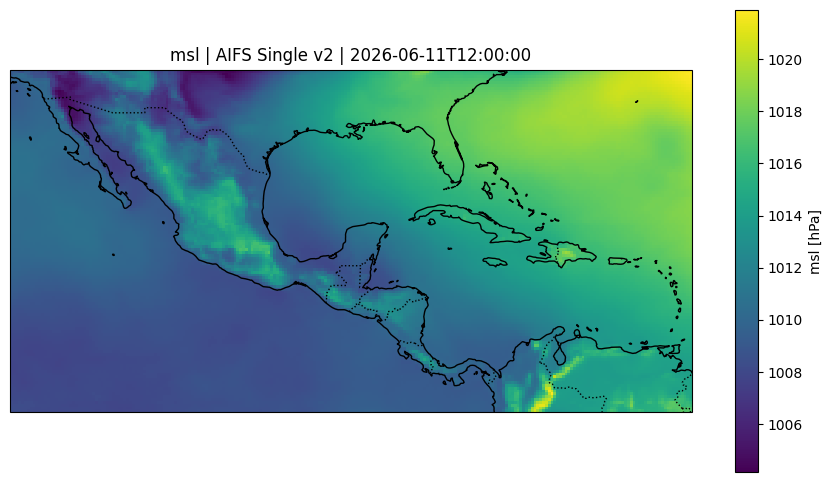

In [ ]:
if regional_dataset is not None:
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    field_to_plot = "msl"
    plot_data = regional_dataset[field_to_plot].isel(
        valid_time=0
    )

    if plot_data.attrs.get("units") == "Pa":
        plot_data = plot_data / 100.0
        plot_data.attrs["units"] = "hPa"

    figure = plt.figure(figsize=(11, 6))
    axis = plt.axes(projection=ccrs.PlateCarree())

    plot_data.plot(
        ax=axis,
        transform=ccrs.PlateCarree(),
        x="longitude",
        y="latitude",
    )

    axis.coastlines()
    axis.add_feature(cfeature.BORDERS, linestyle=":")
    axis.set_title(
        f"{field_to_plot} | AIFS Single v2 | "
        f"{pd.Timestamp(last_state['date']).isoformat()}"
    )

    plt.show()
else:
    print("Gráfica omitida.")

## 17. Guardado del resultado regional

In [ ]:
if regional_dataset is not None:
    filename = (
        "aifs-single-v2_"
        f"{DATE:%Y%m%dT%H%M}_"
        f"lead-{CONFIG.lead_time_hours:03d}h_"
        "regional-validation.nc"
    )
    output_file = CONFIG.output_dir / filename

    encoding = {
        name: {
            "zlib": True,
            "complevel": 4,
            "dtype": "float32",
        }
        for name in regional_dataset.data_vars
    }

    regional_dataset.to_netcdf(
        output_file,
        encoding=encoding,
    )

    print("Guardado en:", output_file.resolve())
else:
    print("Guardado omitido.")

## 18. Resultado de esta etapa y siguiente refactorización

### Este prototipo valida

- inventario de variables de Single v2;
- estados \(t-6\) h y \(t_0\);
- transformaciones de oleaje, suelo y geopotencial;
- integridad estructural de `input_state`;
- inferencia opcional de 6 h;
- interpolación N320 → 0.25°;
- recorte regional y NetCDF pequeño.

### Para el repositorio de GitHub

1. separar `config`, `data`, `inference` y `postprocess`;
2. usar YAML/TOML y una CLI;
3. incorporar `logging`;
4. añadir pruebas unitarias e integración;
5. implementar reintentos de descarga;
6. escribir estados incrementalmente;
7. fijar el entorno en `pyproject.toml` o `environment.yml`;
8. añadir CI sin inferencia GPU completa;
9. completar metadatos CF;
10. comparar contra una salida de referencia de ECMWF.